# Tiny PCA-MLP run

Launch a small PCA-MLP run and view its outputs and results


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import thousandworlds as tw
from thousandworlds.run_model import run

data_dir = Path("dataset")

In [2]:
result = run(
    "pca_mlp",
    "single-complete",
    data_dir=data_dir,
    ppca_iters=30,
    num_steps=3000,
    latent_dim=8,
    hidden_width=16,
    dtype="float32",
)


[ppca] iter    1/30 | sigma2=2.126e-03 | delta=9.979e-01
[ppca] iter    3/30 | sigma2=5.444e-04 | delta=2.699e-05
[ppca] iter    6/30 | sigma2=5.369e-04 | delta=1.123e-06
[ppca] iter    9/30 | sigma2=5.347e-04 | delta=6.145e-07
[ppca] iter   12/30 | sigma2=5.332e-04 | delta=4.428e-07
[ppca] iter   15/30 | sigma2=5.322e-04 | delta=2.941e-07
[ppca] iter   18/30 | sigma2=5.316e-04 | delta=1.744e-07
[ppca] iter   21/30 | sigma2=5.312e-04 | delta=9.511e-08
[ppca] iter   24/30 | sigma2=5.310e-04 | delta=4.936e-08
[ppca] iter   27/30 | sigma2=5.309e-04 | delta=2.485e-08
[ppca] iter   30/30 | sigma2=5.309e-04 | delta=1.240e-08
[mlp] iter  100/3000 | train_mse=5.091637e+01
[mlp] iter  200/3000 | train_mse=4.567450e+01
[mlp] iter  300/3000 | train_mse=4.052014e+01
[mlp] iter  400/3000 | train_mse=3.683826e+01
[mlp] iter  500/3000 | train_mse=3.337670e+01
[mlp] iter  600/3000 | train_mse=3.021959e+01
[mlp] iter  700/3000 | train_mse=2.745145e+01
[mlp] iter  800/3000 | train_mse=2.497288e+01
[mlp]

## Metrics

Let's see how it does on the main metric: RMSE

In [3]:
pd.Series(result["metrics"]["rmse"]["per_variable"], name="rmse")


surface_temperature      14.796066
temperature              11.757925
specific_humidity_dex     0.684260
cloud_fraction            0.101065
u                        10.954678
v                         5.008535
asr                      30.527081
olr                      22.369999
Name: rmse, dtype: float64

## Predictions vs targets

We can also inspects the predictions for specific targets. We can't really visualize 3D climates in one go, but we can look at various 'views' of the outputs (see more examples in [explore_trappist1e.ipynb](explore_trappist1e.ipynb))

### Surface temperature maps

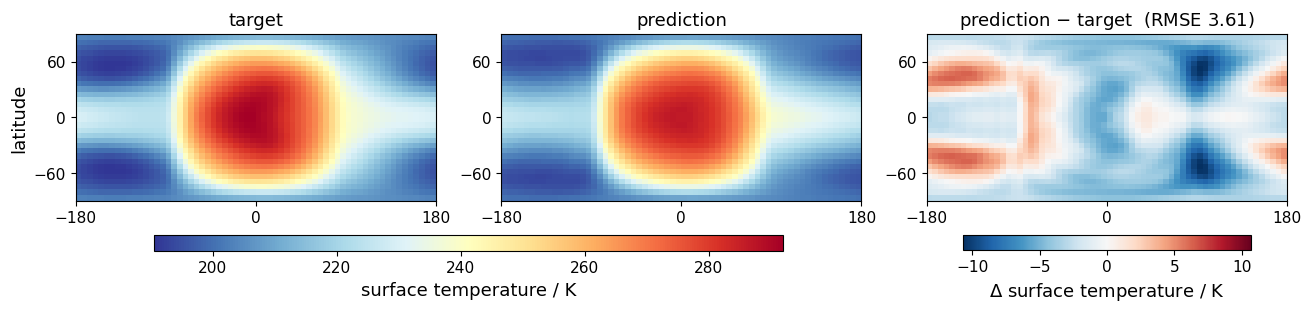

In [4]:
bundle = tw.load("single-complete", data_dir=data_dir)
pred = result["point_predictions"][0]  # (n_test, n_field, lat, lon), aligned with the test set

fig, _ = tw.viz.compare_field(bundle, pred, field="surface_temperature", idx=0)

### Vertical profiles

(<Figure size 900x400 with 2 Axes>,
 <Axes: title={'center': 'specific humidity'}, xlabel='specific humidity / kg kg$^{-1}$', ylabel='pressure / hPa'>)

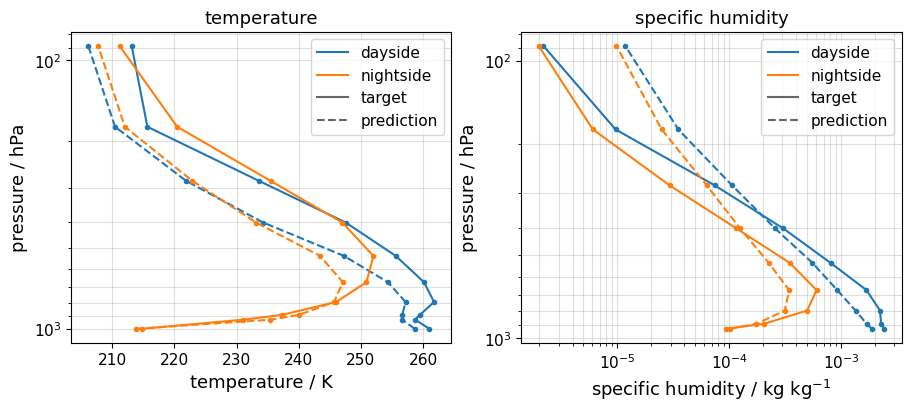

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
tw.viz.profile_comparison(bundle, pred, "temperature", idx=0, ax=axes[0], title="temperature")
tw.viz.profile_comparison(bundle, pred, "specific_humidity", idx=0, ax=axes[1], title="specific humidity")